
### 1. Nazwiska i imiona, grupa studencka oraz numery indeksów studentów z zespołu projektowego
Kossakowski Michał, ACiR 2A, 197589  
Mielniczak Szymon, ACiR 2A, 197956

### 2. Temat zadania projektowego z opisem zadań do wykonania
Projekt 7. (Układ zamknięty z regulatorem P)

Zamodeować i przeprowadzić symulację systemu według podanego schematu blokowego. Umożliwić definiowanie parametrów:  
- k, a, b, A

Program powinien:
- wykreślać bieżące wartości wejścia \( u(t) \) i wyjścia \( y(t) \),
- sprawdzać stabilność układu (test stabilności),
- wykreślać linię pierwiastkową (dla \( k > 0 \)),
- umożliwiać pobudzenie \( u(t) \) w postaci skoku jednostkowego lub sinusoidy.
<br><br>
<img src="schemat.png" width="1200">


### 3. Sposób modelowania
Model przyjęty:
$$
y''(t) + (a + b)y'(t) + (ab + k)y(t) = Ak u(t)
$$

- model postaci różniczkowej,
- sygnały pobudzające:
    - skok jednostkowy,
    - sinusoida.

### 4. Sposób wykonania zadania – zastosowane rozwiązanie numeryczne
Zastosowana metoda: **metoda Taylora**  
Obliczamy numerycznie:
- drugą pochodną \( y''(t) \),
- pierwszą pochodną \( y'(t) \),
- wartość \( y(t) \) w kolejnych krokach czasowych.

### 5. Sposób prezentacji danych
Wykresy rysowane przy użyciu:
- biblioteki **Matplotlib**,
- biblioteki **control** (do linii pierwiastkowych).

### 6. Przykładowe wyniki symulacyjne


Układ stabilny
Bieguny: [-1.5+1.32287566j -1.5-1.32287566j]


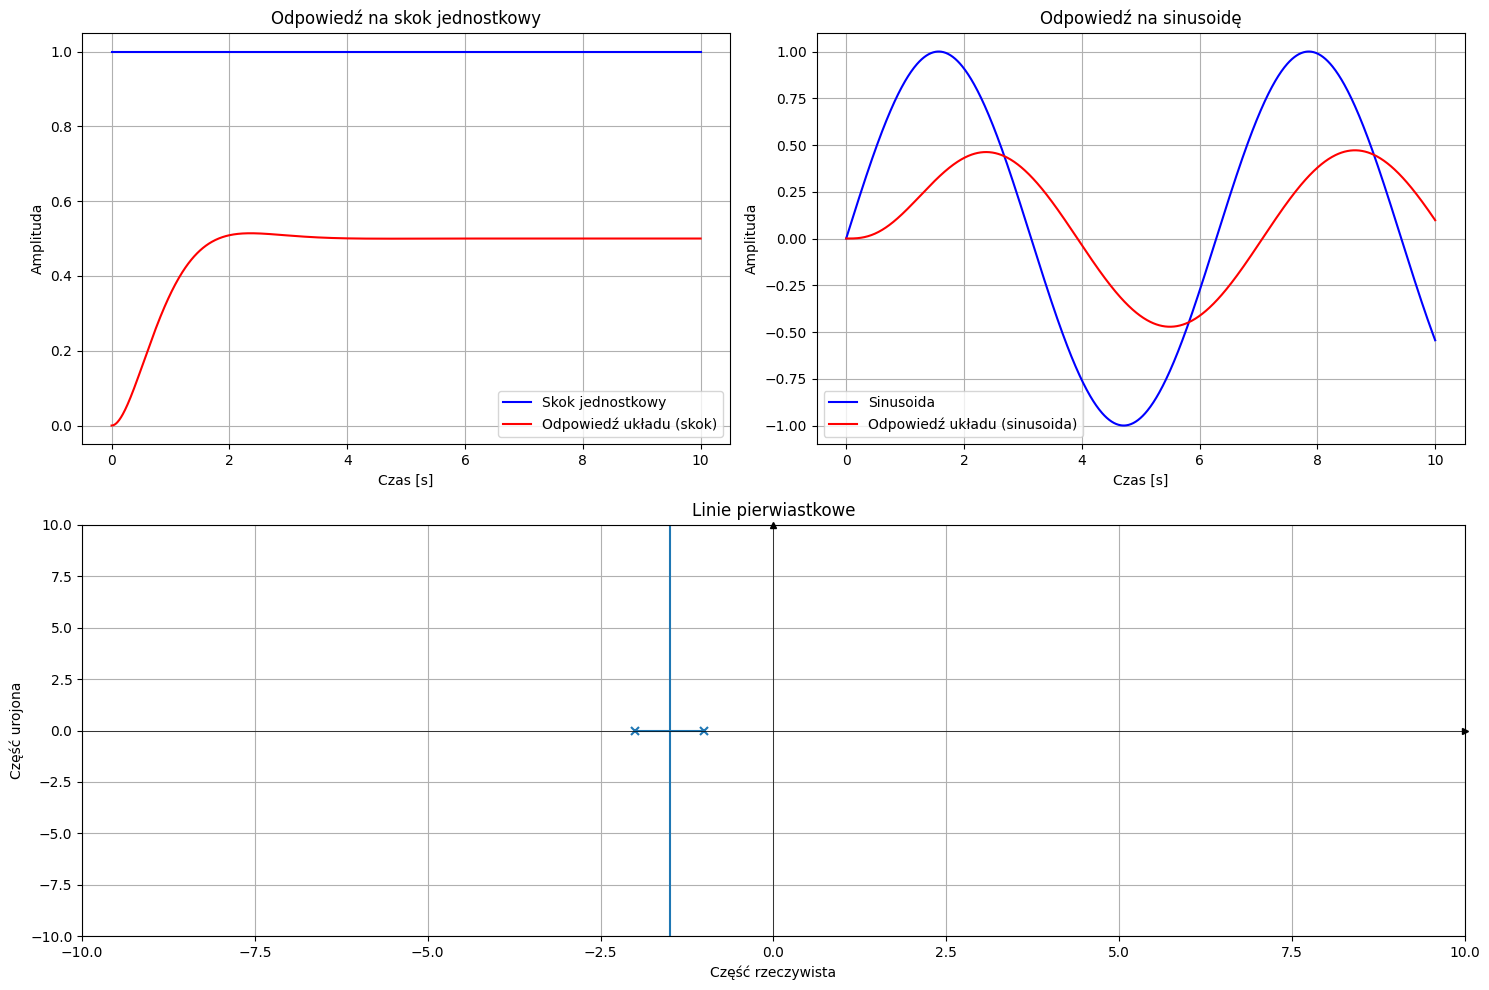

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from control import tf, root_locus

def symuluj_odpowiedz(k, a, b, t, sygnal_wejsciowy, A):
    n = len(t)
    h = t[1] - t[0]
    y = np.zeros(n)
    y_p = np.zeros(n)
    y_pp = np.zeros(n)
    for i in range(n - 1):
        y_pp[i] = - (a + b) * y_p[i] - (a * b + k) * y[i] + A * k * sygnal_wejsciowy[i]
        y_p[i + 1] = y_p[i] + h * y_pp[i]
        y[i + 1] = y[i] + h * y_p[i] + (h ** 2 / 2) * y_pp[i]
    return t, y

def sprawdz_stabilnosc(a, b, k, A):
    bieguny = np.roots([A, (a + b), (a * b) + k])
    return np.all(np.real(bieguny) < 0), bieguny

def rysuj_linie_pierwiastkowe(a, b, A, ax):
    licznik = [A]
    mianownik = [1, (a + b), (a * b)]
    system = tf(licznik, mianownik)
    
    ax.clear()
    root_locus(system, plot=True, grid=True, ax=ax)
    
    x_min, x_max = -10, 10
    y_min, y_max = -10, 10
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])
    ax.set_title("Linie pierwiastkowe")
    ax.set_xlabel("Część rzeczywista")
    ax.set_ylabel("Część urojona")
    ax.grid(True)
    
    ax.plot([x_max], [0], '>k', markersize=5, clip_on=False)
    ax.plot([0], [y_max], '^k', markersize=5, clip_on=False)

k, a, b, A = 2.0, 1.0, 2.0, 1.0
t = np.linspace(0, 10, 1000)
sygnal_skok = np.heaviside(t, 1)
sygnal_sin = np.sin(t)

t_skok, y_skok = symuluj_odpowiedz(k, a, b, t, sygnal_skok, A)
t_sin, y_sin = symuluj_odpowiedz(k, a, b, t, sygnal_sin, A)

# Sprawdzenie stabilności
stabilny, bieguny = sprawdz_stabilnosc(a, b, k, A)
print(f"Układ {'stabilny' if stabilny else 'niestabilny'}")
print(f"Bieguny: {bieguny}")

plt.figure(figsize=(15, 10))

# Wykres odpowiedzi na skok
plt.subplot(2, 2, 1)
plt.plot(t_skok, sygnal_skok, label="Skok jednostkowy", color='blue')
plt.plot(t_skok, y_skok, label="Odpowiedź układu (skok)", color='red')
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.title("Odpowiedź na skok jednostkowy")
plt.legend()
plt.grid(True)

# Wykres odpowiedzi na sinusoidę
plt.subplot(2, 2, 2)
plt.plot(t_sin, sygnal_sin, label="Sinusoida", color='blue')
plt.plot(t_sin, y_sin, label="Odpowiedź układu (sinusoida)", color='red')
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.title("Odpowiedź na sinusoidę")
plt.legend()
plt.grid(True)

# Wykres linii pierwiastkowych
ax3 = plt.subplot(2, 1, 2)
rysuj_linie_pierwiastkowe(a, b, A, ax3)

plt.tight_layout()
plt.show()


### 7. Wnioski końcowe
- Symulacja działa poprawnie, generuje oczekiwane odpowiedzi \( y(t) \).
- Stabilność systemu jest poprawnie analizowana na podstawie biegunów.
- Linie pierwiastkowe umożliwiają wizualizację stabilności dla różnych \( k \).
- Ewentualne ulepszenia:
    - obsługa większej liczby typów sygnałów,
    - automatyczne dobieranie zakresów osi,
    - zapis wyników do pliku.

### 8. Dodatki – wybrane fragmenty programu


In [19]:

def sprawdz_stabilnosc(a, b, k, A):
    bieguny = np.roots([A, (a + b), (a * b) + k])
    return np.all(np.real(bieguny) < 0), bieguny

def rysuj_linie_pierwiastkowe(a, b, A):
    system = tf([A], [1, (a + b), a * b])
    root_locus(system, Plot=True, grid=True)
    plt.show()
